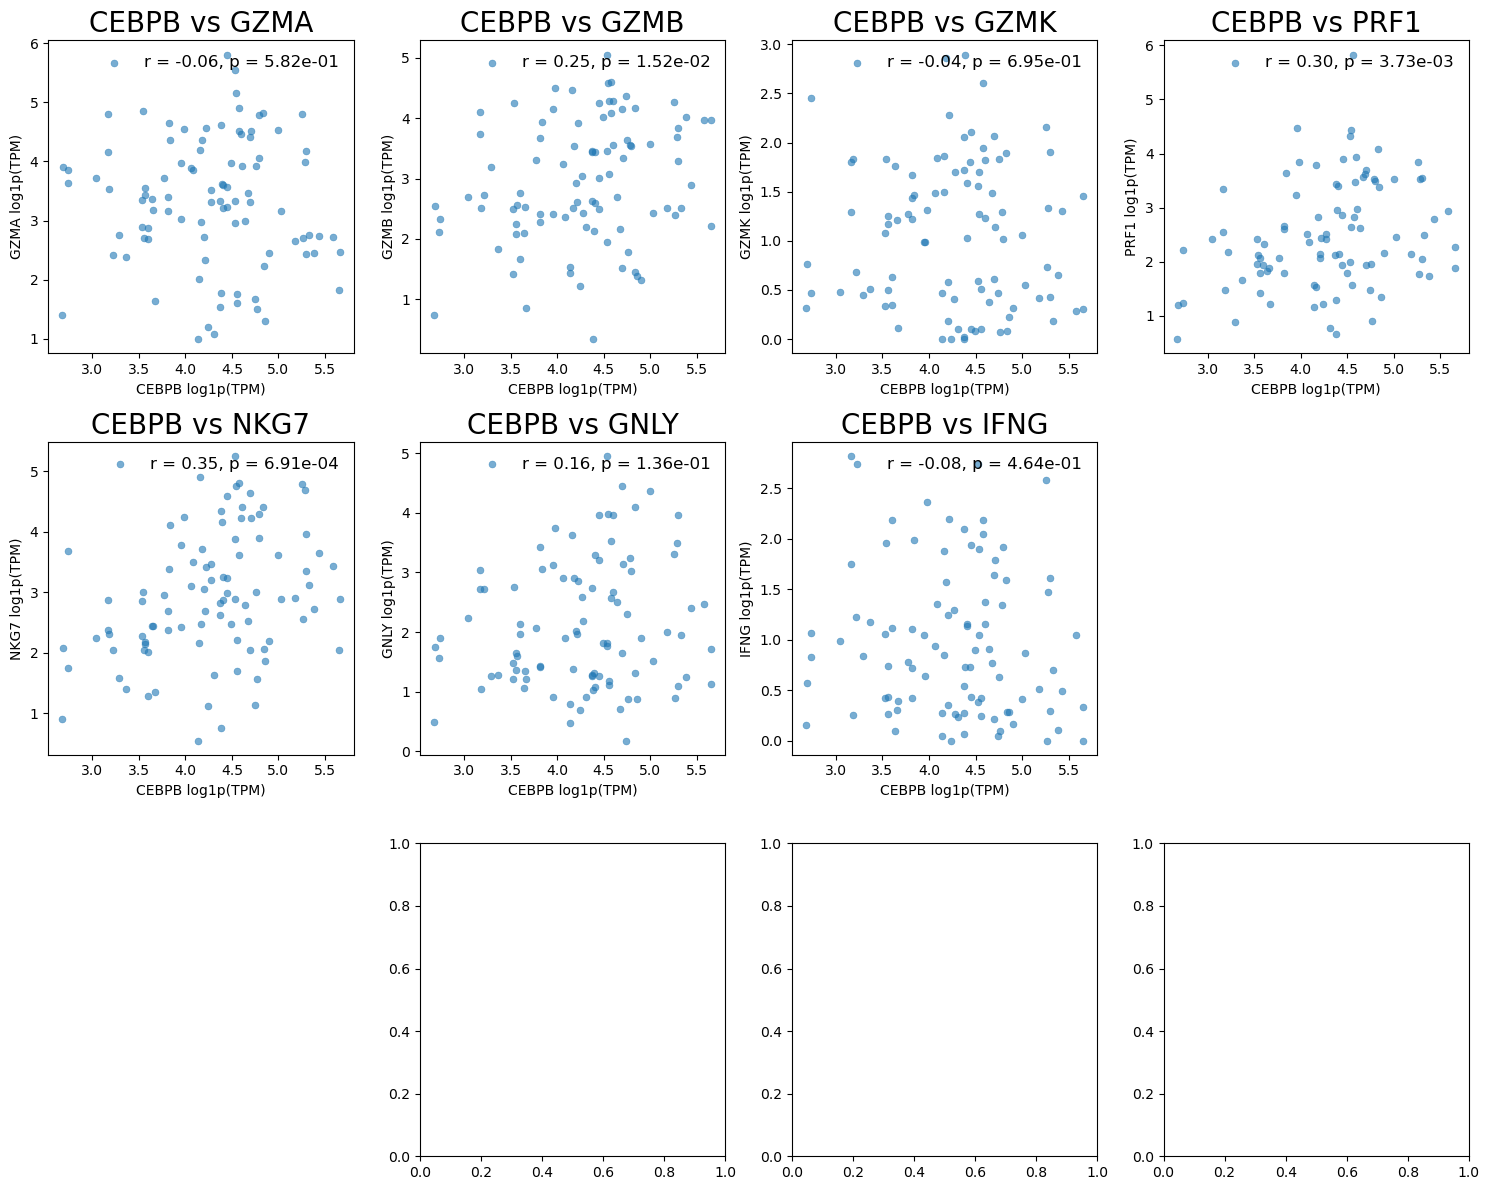

In [8]:
import os
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 폴더 경로 및 유전자 목록
data_dir = "/home/Data_Drive_8TB/kykim/2. CRC/Bulk_RNA_seq/extracted/"
reference_gene = 'CEBPB'
target_genes = ['GZMA', 'GZMB', 'GZMK', 'PRF1', 'NKG7', 'GNLY', 'IFNG']
genes_of_interest = [reference_gene] + target_genes

# 유전자 x 샘플 구조로 저장할 딕셔너리 초기화 (raw TPM)
expression_dict = {gene: {} for gene in genes_of_interest}

# 파일 반복
for file_name in os.listdir(data_dir):
    if not file_name.endswith(".tsv"):
        continue

    sample_id = file_name.replace(".tsv", "")
    file_path = os.path.join(data_dir, file_name)

    # 파일 읽기 및 주석 제거
    with open(file_path, 'r') as f:
        lines = f.readlines()
    clean_lines = [line for line in lines if not line.startswith('#')]

    # DataFrame 생성
    df = pd.read_csv(StringIO(''.join(clean_lines)), sep='\t')

    # QC 행 제거
    qc_rows = ['N_unmapped', 'N_multimapping', 'N_noFeature', 'N_ambiguous']
    df = df[~df['gene_id'].isin(qc_rows)]

    # 수치형 컬럼 중 있는 것만 선택
    numeric_cols = ['tpm_unstranded']
    if not all(col in df.columns for col in numeric_cols):
        continue

    df_numeric = df[['gene_name'] + numeric_cols].copy()

    # 중복 gene_name 평균
    df_grouped = df_numeric.groupby('gene_name', as_index=False)[numeric_cols].mean().set_index('gene_name')

    # 필요한 유전자 모두 있는 경우
    if all(gene in df_grouped.index for gene in genes_of_interest):
        for gene in genes_of_interest:
            val = df_grouped.loc[gene, 'tpm_unstranded']  # <-- log1p 제거 (raw TPM 저장)
            expression_dict[gene][sample_id] = val

# 유전자 x 샘플 형태의 DataFrame 생성 후 전치 (행: 샘플, 열: 유전자)
exp_df = pd.DataFrame(expression_dict).T  # (genes x samples)
exp_df = exp_df.T  # transpose to samples x genes

# ---- log1p 전처리를 최종 DataFrame에 일괄 적용 ----
exp_df = np.log1p(exp_df)

# ----------------- Plotting -----------------
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i, gene in enumerate(target_genes):
    ax = axes[i]
    x = exp_df[reference_gene]
    y = exp_df[gene]

    r, p = pearsonr(x, y)

    # 산점도 + 범례(label) 추가
    sns.scatterplot(
        x=x, y=y, ax=ax, s=25, alpha=0.6, edgecolor=None,
        label=f"r = {r:.2f}, p = {p:.2e}"
    )

    ax.set_title(f'{reference_gene} vs {gene}', fontsize=20)
    ax.set_xlabel(f'{reference_gene} log1p(TPM)')
    ax.set_ylabel(f'{gene} log1p(TPM)')

    # 범례 위치 조정
    ax.legend(loc="best", fontsize=12, frameon=False)

# 남는 subplot 지우기
for j in range(i + 1, 9):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

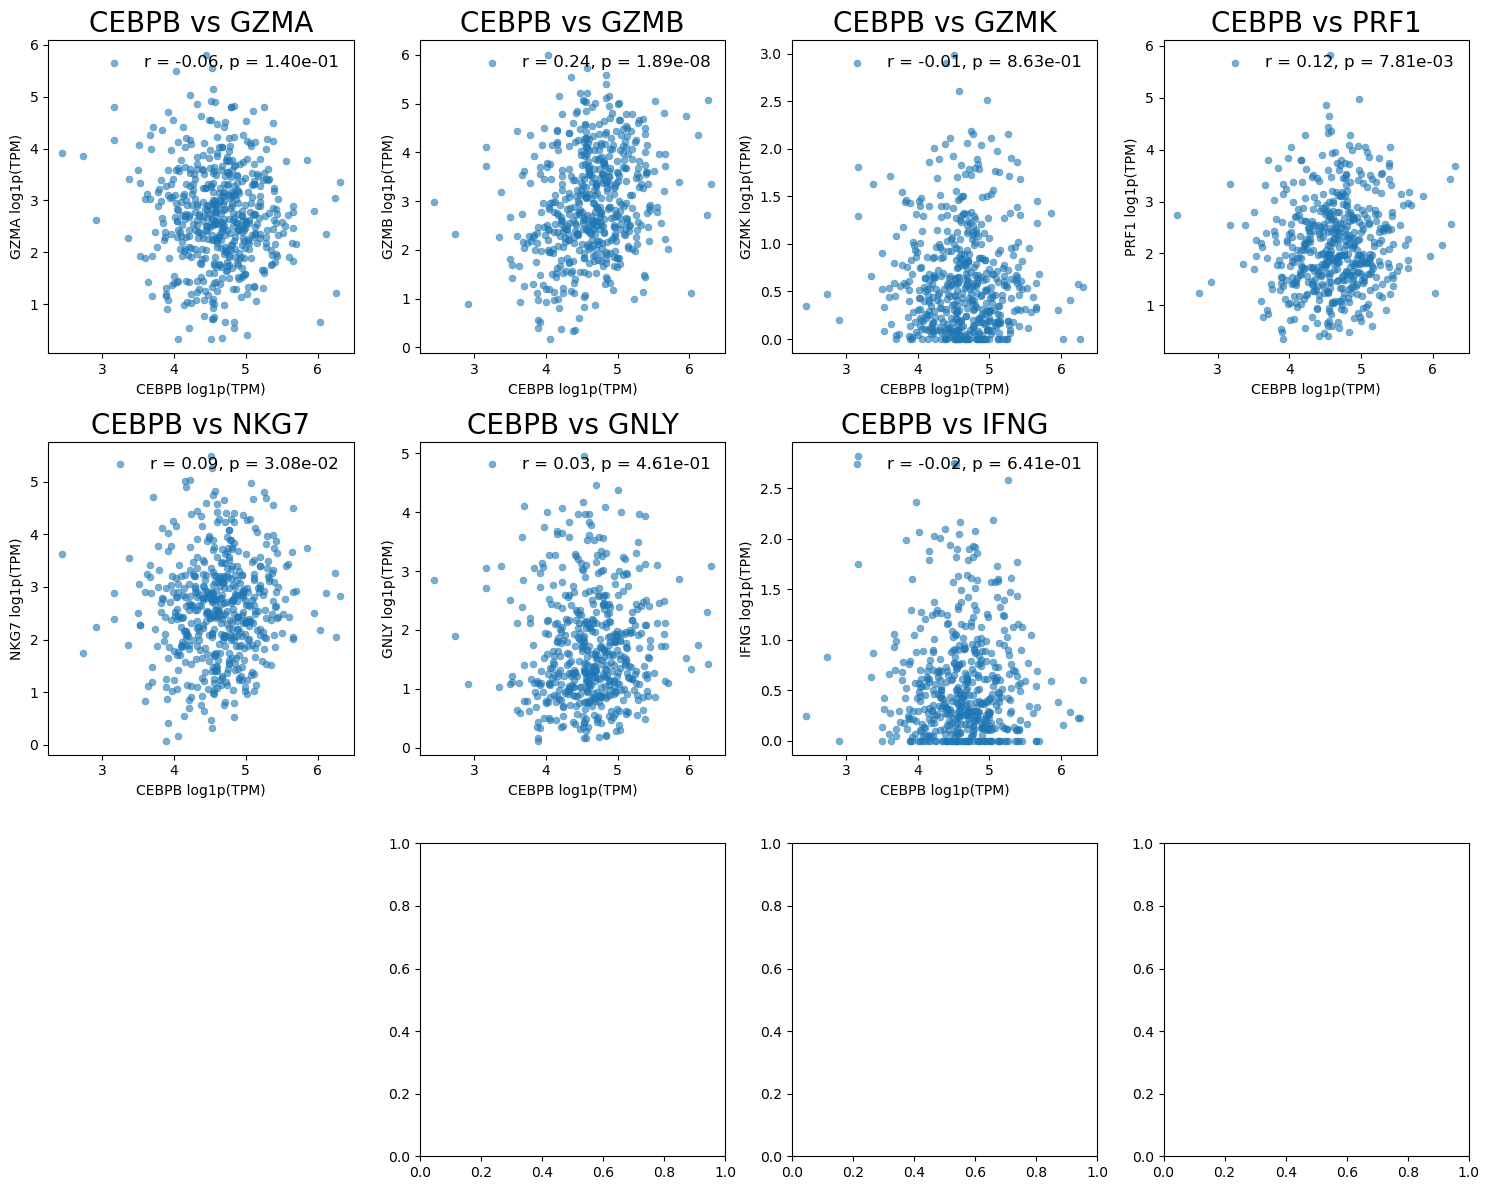

In [10]:
import os
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 폴더 경로 및 유전자 목록
data_dir = "/home/Data_Drive_8TB/kykim/2. CRC/Bulk_RNA_seq/extracted/"
reference_gene = 'CEBPB'
target_genes = ['GZMA', 'GZMB', 'GZMK', 'PRF1', 'NKG7', 'GNLY', 'IFNG']
genes_of_interest = [reference_gene] + target_genes

# 유전자 x 샘플 구조로 저장할 딕셔너리 초기화 (raw TPM)
expression_dict = {gene: {} for gene in genes_of_interest}

# 파일 반복
for file_name in os.listdir(data_dir):
    if not file_name.endswith(".tsv"):
        continue

    sample_id = file_name.replace(".tsv", "")
    file_path = os.path.join(data_dir, file_name)

    # 파일 읽기 및 주석 제거
    with open(file_path, 'r') as f:
        lines = f.readlines()
    clean_lines = [line for line in lines if not line.startswith('#')]

    # DataFrame 생성
    df = pd.read_csv(StringIO(''.join(clean_lines)), sep='\t')

    # QC 행 제거
    qc_rows = ['N_unmapped', 'N_multimapping', 'N_noFeature', 'N_ambiguous']
    df = df[~df['gene_id'].isin(qc_rows)]

    # 수치형 컬럼 중 있는 것만 선택
    numeric_cols = ['tpm_unstranded']
    if not all(col in df.columns for col in numeric_cols):
        continue

    df_numeric = df[['gene_name'] + numeric_cols].copy()

    # 중복 gene_name 평균
    df_grouped = df_numeric.groupby('gene_name', as_index=False)[numeric_cols].mean().set_index('gene_name')

    # 필요한 유전자 모두 있는 경우
    if all(gene in df_grouped.index for gene in genes_of_interest):
        for gene in genes_of_interest:
            val = df_grouped.loc[gene, 'tpm_unstranded']  # <-- log1p 제거 (raw TPM 저장)
            expression_dict[gene][sample_id] = val

# 유전자 x 샘플 형태의 DataFrame 생성 후 전치 (행: 샘플, 열: 유전자)
exp_df = pd.DataFrame(expression_dict).T  # (genes x samples)
exp_df = exp_df.T  # transpose to samples x genes

# ---- log1p 전처리를 최종 DataFrame에 일괄 적용 ----
exp_df = np.log1p(exp_df)

# ----------------- Plotting -----------------
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
axes = axes.flatten()

for i, gene in enumerate(target_genes):
    ax = axes[i]
    x = exp_df[reference_gene]
    y = exp_df[gene]

    r, p = pearsonr(x, y)

    # 산점도 + 범례(label) 추가
    sns.scatterplot(
        x=x, y=y, ax=ax, s=25, alpha=0.6, edgecolor=None,
        label=f"r = {r:.2f}, p = {p:.2e}"
    )

    ax.set_title(f'{reference_gene} vs {gene}', fontsize=20)
    ax.set_xlabel(f'{reference_gene} log1p(TPM)')
    ax.set_ylabel(f'{gene} log1p(TPM)')

    # 범례 위치 조정
    ax.legend(loc="best", fontsize=12, frameon=False)

# 남는 subplot 지우기
for j in range(i + 1, 9):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()